In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import lmfit
import pandas as pd

from bio_optics.water.reflectance import bi, bi_jax
from bio_optics.helper import resampling
from bio_optics.atmosphere import downwelling_irradiance
from bio_optics.water import absorption, backscattering, fluorescence, attenuation

# Consistency Check IOP model implementation  
Model implementations:
- bi.py (in bio_optics_dev)
- bi_jax.py (which is a different implementation)
- my 'old' implementation

First check:  
- Rrs
  
Input parameters:  
Diatoms: 1 µg/l, CDOM = 0.3 1/m, NAP = 1 mg/l, nothing else
 

In [2]:
def set_default_parameters(AlgaeGroupType='Standardv3'):
    ## by Default:
    # - all Phytoplankton groups are value=0, min=0, max=1000 (C_5=10, C_7=1), vary = False
    # - C_Y value=0, min=0, max=30, vary=True
    # - C_ism value=0, min=0, max=100, vary=True
    # - fluorescence all vary = False
    # - offset vary = False
    params = lmfit.Parameters()                             # v3 ,      SummerBloom
    params.add('C_0', value=0, min=0, max=100, vary=False)  # Diatoms
    params.add('C_1', value=0, min=0, max=100, vary=False)  # green
    params.add('C_2', value=0, min=0, max=100, vary=False)  # cryptophyte
    params.add('C_3', value=0, min=0, max=100, vary=False)  # cyano blue
    params.add('C_4', value=0, min=0, max=100, vary=False)  # cyano red
    params.add('C_5', value=0, min=0, max=10, vary=False)   # coccolithophores , Phaeocystis: other ranges
    params.add('C_6', value=0, min=0, max=100, vary=False)  # dinoflagellates
    params.add('C_7', value=0, min=0, max=1, vary=False)    # case-1  , Noctiluca: other ranges
    params.add('C_Y', value=0, min=0, max=30, vary=True)
    params.add('C_ism', value=0, min=0, max=100, vary=True)
    params.add('L_fl_lambda0', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycocyanin', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycoerythrin', value=0, min=0, max=0.2, vary=False)
    params.add('b_ratio_C_0', value=0.002, vary=False)  # Diatoms 0.0058; HEREONweb: 0.002
    params.add('b_ratio_C_1', value=0.007, vary=False)  # green 0.007, HEREONweb: 0.007
    params.add('b_ratio_C_2', value=0.002, vary=False)  # cryptophyte 0.0042, HEREONweb: 0.002
    params.add('b_ratio_C_3', value=0.003, vary=False)  # cyano blue 0.0082, HEREONweb: 0.003
    params.add('b_ratio_C_4', value=0.003, vary=False)  # cyano red 0.001, HEREONweb: 0.003
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_5', value=0.0034, vary=False)  # Phaeocystis: change to 0.0034
    elif AlgaeGroupType == 'HEREONgold':
        params.add('b_ratio_C_5', value=0.002, vary=False)
    else:
        params.add('b_ratio_C_5', value=0.0129,
                   vary=False)  # coccolithophores 0.0129, , HEREONweb: 0.007, Phaeocystis: change to 0.0034
    params.add('b_ratio_C_6', value=0.0209, vary=False)  # dinoflagellates 0.0209, HEREONweb: not available
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_7', value=0.0209, vary=False)  # Noctiluca: change to 0.0209
    else:
        params.add('b_ratio_C_7', value=0.007,
                   vary=False)  # case-1 0.0109, HEREONweb: 0.007, Noctiluca: change to 0.0209
    params.add('b_ratio_md', value=0.0216, min=0.021, max=0.3756, vary=False)  # max=0.0756 #todo: vary turn off
    params.add('b_ratio_bd', value=0.0216, min=0.021, max=0.3756, vary=False)  # max=0.0756 #todo: vary turn off
    params.add('b_ratio_d', value=0.0216, min=0.021, max=0.3756, vary=False)
    params.add('A_md', value=13.4685e-3, vary=False)
    params.add('A_bd', value=0.3893e-3, vary=False)
    params.add('S_md', value=10.3845e-3, vary=False)
    params.add('S_bd', value=15.7621e-3, vary=False)
    params.add('S_cdom', value=0.020, min=0.018, max=0.022, vary=True) # Helsinki: 0.018 -0.022; test Baltic: min =0.01
    params.add('C_md', value=12.1700e-3, vary=False)
    params.add('C_bd', value=0.9994e-3, vary=False)
    params.add('K', value=0, min=0, vary=False)
    params.add('lambda_0_cdom', value=440, vary=False)
    params.add('lambda_0_md', value=550, vary=False)
    params.add('lambda_0_bd', value=550, vary=False)
    params.add('lambda_0_c_d', value=550, vary=False)
    params.add('lambda_0_phy', value=676, vary=False)
    params.add('gamma_d', value=0.3835, vary=False)
    params.add('x0', value=1, vary=False)
    params.add('x1', value=10, vary=False)
    params.add('x2', value=-1.3390, min=-1.3390 - 0.0618, max=-1.3390 + 0.0618, vary=False)
    params.add('A_phy', value=0.0237, vary=False)
    params.add('E0', value=1, vary=False)
    params.add('E1', value=0.8987, vary=False)
    params.add('W', value=0.75, vary=False)
    params.add('fwhm1', value=25, vary=False)
    params.add('fwhm2', value=50, vary=False)
    params.add('fwhm_phycocyanin', value=20, vary=False)
    params.add('fwhm_phycoerythrin', value=20, vary=False)
    params.add('lambda_C1', value=685, vary=False)
    params.add('lambda_C2', value=730, vary=False)
    params.add('lambda_C_phycocyanin', value=644, vary=False)
    params.add('lambda_C_phycoerythrin', value=573, vary=False)
    params.add('double', value=True, vary=False)
    params.add('interpolate', value=False, vary=False) # value=True
    params.add("Gw0", value=0.05881474, vary=False)
    params.add("Gw1", value=0.05062697, vary=False)
    params.add("Gp0", value=0.03997009, vary=False)
    params.add("Gp1", value=0.1398902, vary=False)
    params.add('error_method', value=0, vary=False)
    params.add('theta_sun', value=np.radians(30), min=np.radians(0), max=np.radians(90), vary=False)
    params.add('theta_view', value=np.radians(1e-10), min=np.radians(1e-10), max=np.radians(90), vary=False)
    params.add('n1', value=1, vary=False)
    params.add('n2', value=1.33, vary=False)
    params.add('kappa_0', value=1.0546, vary=False)
    params.add('fresh', value=False, vary=False)
    params.add('T_W', value=25, min=0, max=40, vary=False)
    params.add('T_W_0', value=20, vary=False)
    params.add('P', value=1013.25, vary=False)
    params.add('AM', value=1, vary=False)
    params.add('RH', value=60, vary=False)
    params.add('H_oz', value=0.38, vary=False)
    params.add('WV', value=2.5, vary=False)
    params.add('alpha', value=1.317, vary=False)
    params.add('beta', value=0.2606, vary=False)
    params.add('g_dd', value=0.02, min=-1, max=10, vary=False)  # glint correction
    params.add('g_dsr', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('g_dsa', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('d_r', value=0, min=0, max=0.1, vary=False)
    params.add('f_dd', value=1, vary=False)
    params.add('f_ds', value=1, vary=False)
    params.add('offset', value=0, min=-0.1, max=0.1, vary=False)
    params.add('fit_surface', value=False, vary=False)
    return params


def set_parameters_byDict(pDict, params):
    for key in pDict.keys():
        thisD = pDict[key]
        params.add(key, value=thisD['value'], min=thisD['min'], max=thisD['max'], vary=True)
    return params


def setDictValues(value, vmin, vmax):
    dd = {'value': value, 'min': vmin, 'max': vmax}
    return dd

In [3]:
IOPDict = {
    'C_0': 1.,
    'C_1': 0.,
    'C_2': 0.,
    'C_3': 0.,
    'C_4': 0.,
    'C_5': 0.,
    'C_6': 0.,
    'C_Y': 0.3,
    'C_ism': 1.,
    # 'S_md': 'Snap [1/nm]',
    # 'S_cdom' : 'Sg [1/nm]',
    'L_fl_lambda0' : 0.,  # remove fluoresence
    'L_fl_phycocyanin': 0. # remove fluoresence
}

params = set_default_parameters()
for p in IOPDict.keys():
    params.add(p, value=IOPDict[p])

## Bi in bio_optics_dev

In [4]:
AlgaeGroupType = 'HEREON'
wavelengths = np.arange(400., 800., 1.)

# global inputs that don't change with fit params
a_md_spec_res = absorption.a_md_spec(wavelengths=wavelengths)
a_bd_spec_res = absorption.a_bd_spec(wavelengths=wavelengths)
a_w_res = resampling.resample_a_w(wavelengths=wavelengths)
if AlgaeGroupType == 'HEREON':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
# if AlgaeGroupType == 'Standard':
#     a_i_spec_res = resampling.resample_a_i_spec_EnSAD_Standardv3(wavelengths=wavelengths) # prototype v3, PACEv3
#     b_i_spec_res = resampling.resample_b_i_spec_EnSAD_Standardv3(wavelengths=wavelengths) # prototype v3, PACEv3
# if AlgaeGroupType == 'Summer':
#     a_i_spec_res = resampling.resample_a_i_spec_EnSAD_SummerBloomsv3(wavelengths=wavelengths) # prototype v3, PACEv3
#     b_i_spec_res = resampling.resample_b_i_spec_EnSAD_SummerBloomsv3(wavelengths=wavelengths) # prototype v3, PACEv3
# if AlgaeGroupType == 'HEREONgold': #HEREON (- coccolithophore + goldalgae) + dinoflagellate
#     a_i_spec_res = resampling.resample_a_i_spec_EnSADandGold(wavelengths=wavelengths)  # AQUATIME Vortsjarv, HEATWISE Mueggelsee
#     b_i_spec_res = resampling.resample_b_i_spec_EnSADandGold(wavelengths=wavelengths)  # AQUATIME Vortsjarv, HEATWISE Mueggelsee
b_bw_res = backscattering.bb_w(wavelengths=wavelengths, fresh=False)

da_W_div_dT_res = resampling.resample_da_w_div_dT(wavelengths=wavelengths)
h_C_res = fluorescence.h_C_double(wavelengths=wavelengths, W=0.75)
h_C_phycocyanin_res = fluorescence.h_C(wavelengths=wavelengths, fwhm=20, lambda_C=644)
h_C_phycoerythrin_res =fluorescence.h_C(wavelengths=wavelengths, fwhm=20, lambda_C=573)
omega_d_lambda_0_res = attenuation.omega_d_lambda_0()

E_0_res = resampling.resample_E0(wavelengths=wavelengths)
a_oz_res = resampling.resample_a_oz(wavelengths=wavelengths)
a_ox_res = resampling.resample_a_ox(wavelengths=wavelengths)
a_wv_res = resampling.resample_a_wv(wavelengths=wavelengths)
n2_res = resampling.resample_n(wavelengths=wavelengths)

E_dd_res = downwelling_irradiance.Ed_d(wavelengths=wavelengths)
E_dsa_res = downwelling_irradiance.Ed_sa(wavelengths=wavelengths)
E_dsr_res = downwelling_irradiance.Ed_sr(wavelengths=wavelengths)
E_d_res = E_dd_res + E_dsa_res + E_dsr_res

In [5]:
R_rs_sim = bi.forward(parameters=params,
                      wavelengths=wavelengths,
                      a_md_spec_res=a_md_spec_res,
                      a_bd_spec_res=a_bd_spec_res,
                      a_w_res=a_w_res,
                      a_i_spec_res=a_i_spec_res,
                      bb_w_res=b_bw_res,
                      bb_i_spec_res=b_i_spec_res,
                      h_C_res=h_C_res,
                      h_C_phycocyanin_res=h_C_phycocyanin_res,
                      h_C_phycoerythrin_res=h_C_phycoerythrin_res,
                      da_w_div_dT_res=da_W_div_dT_res,
                      E0_res=E_0_res,
                      a_oz_res=a_oz_res,
                      a_ox_res=a_ox_res,
                      a_wv_res=a_wv_res,
                      Ed_d_res=E_dd_res,
                      Ed_sa_res=E_dsa_res,
                      Ed_sr_res=E_dsr_res,
                      Ed_res=E_d_res,
                      n2_res=n2_res,
                      Ls_Ed=[])

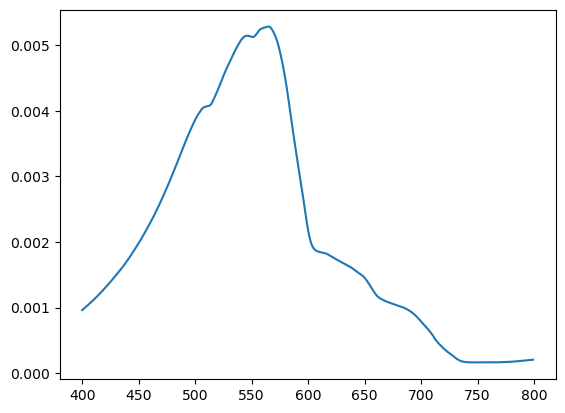

In [6]:
plt.plot(wavelengths, R_rs_sim[:], '-')
plt.show()

## Bi_jax in bio_optics_dev

In [7]:
pre_base = bi_jax.precompute(wavelengths)
pre = {**pre_base}

In [8]:
R_rs_sim_jax = bi_jax.forward(params, pre)

## Compare Spectra

In [11]:
bipath = "D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\compare_implementations\IOP_spectra_outputs_BiWeb_C0_1_else0_NAP1_CDOM0.3.csv"
biweb = pd.read_csv(bipath, header=0)
biweb

,wavelen,aph,ad,acdom,bph,bd,aw,bw,ap,agp,bp,at,bt,bbph,bbd,bbp,bbw,bbt,Rrs_L11,Rrs_AM03
0,350,2.649565e-02,0.129750,1.482277,0.222945,0.572049,0.000879,0.009947,0.156246,1.638524,0.794994,1.639402,0.804942,0.000446,0.012356,0.012802,0.004974,0.017776,0.000494,0.000465
1,352,2.649568e-02,0.127259,1.422576,0.222764,0.573009,0.000910,0.009701,0.153754,1.576331,0.795773,1.577241,0.805474,0.000446,0.012377,0.012823,0.004850,0.017673,0.000510,0.000481
2,354,2.649572e-02,0.124821,1.365614,0.222584,0.573927,0.000950,0.009461,0.151317,1.516931,0.796511,1.517881,0.805972,0.000445,0.012397,0.012842,0.004731,0.017573,0.000526,0.000498
3,356,2.649580e-02,0.122437,1.311458,0.222405,0.574803,0.000991,0.009230,0.148932,1.460390,0.797209,1.461382,0.806438,0.000445,0.012416,0.012861,0.004615,0.017475,0.000542,0.000515
4,358,2.649595e-02,0.120104,1.260011,0.222228,0.575640,0.001035,0.009005,0.146600,1.406611,0.797867,1.407646,0.806873,0.000444,0.012434,0.012878,0.004503,0.017381,0.000559,0.000532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,892,3.310543e-07,0.013557,0.000057,0.221422,0.476671,6.302232,0.000197,0.013558,0.013614,0.698092,6.315847,0.698289,0.000443,0.010296,0.010739,0.000098,0.010837,0.000069,0.000071
272,894,3.024693e-07,0.013549,0.000054,0.221358,0.476258,6.407523,0.000195,0.013550,0.013604,0.697616,6.421127,0.697811,0.000443,0.010287,0.010730,0.000097,0.010827,0.000068,0.000070
273,896,2.763558e-07,0.013542,0.000052,0.221295,0.475846,6.502164,0.000193,0.013542,0.013594,0.697142,6.515758,0.697335,0.000443,0.010278,0.010721,0.000097,0.010817,0.000067,0.000069
274,898,2.525000e-07,0.013534,0.000050,0.221233,0.475436,6.608917,0.000191,0.013534,0.013585,0.696668,6.622501,0.696860,0.000442,0.010269,0.010712,0.000096,0.010808,0.000066,0.000068


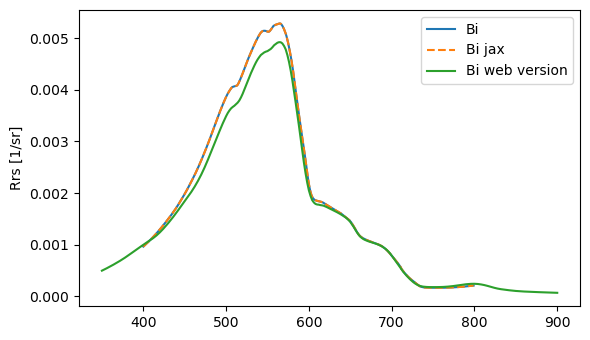

In [17]:
fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(wavelengths, R_rs_sim[:], '-', label='Bi')
ax.plot(wavelengths, R_rs_sim_jax[:], '--', label='Bi jax')
ax.plot(biweb.wavelen, biweb.Rrs_L11, '-', label= 'Bi web version')
ax.legend()
ax.set_ylabel('Rrs [1/sr]')
fig.tight_layout()
plt.show()